In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

# Generate Data

In [3]:
X_train = np.linspace(-1, 1, 20)

In [4]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [5]:
X_test = np.linspace(-1, 1, 20)

In [6]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

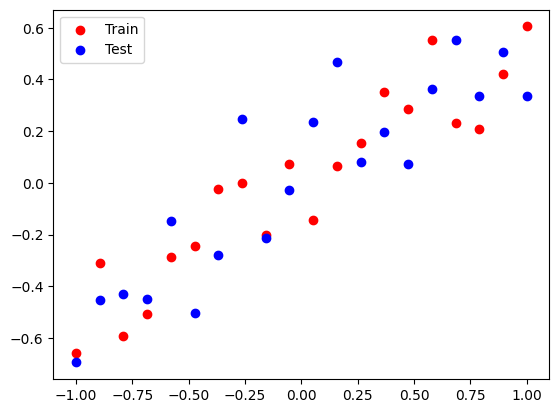

In [7]:
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.legend()
plt.show()

# Regression Model

In [8]:
model_1 = Sequential()
model_1.add(Dense(128, input_dim=1, activation="relu"))
model_1.add(Dense(128, activation="relu"))
model_1.add(Dense(1, activation="linear"))
adam = Adam(learning_rate=0.01)


model_1.compile(loss='mse', optimizer=adam, metrics=['mse'])


history = model_1.fit(X_train, y_train, epochs=400, 
                    validation_data = (X_test, y_test),
                    verbose=False)

/home/midori/Desktop/Nural_Network/nural_venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777908482.517321    4084 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [12]:
model_1.save('regression_without_dropout.keras')

In [10]:
from tensorflow.keras.models import load_model

In [13]:
regression_without_dropout = load_model('regression_without_dropout.keras')

In [ ]:
# evaluate the model

# MSE calculation
# This is tuple unpacking.
# keras returns [loss,mse]
# [ MSE, MSE ]

result1_train = regression_without_dropout.evaluate(X_train, y_train, verbose=0)
result1_test = regression_without_dropout.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(result1_train, result1_test))

Train: [0.004373291973024607, 0.004373291973024607], Test: [0.04650864005088806, 0.04650864005088806]


In [15]:
y_pred_1 = regression_without_dropout.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [18]:
y_pred_1.shape

(20, 1)

In [19]:
y_pred_1 = y_pred_1.flatten()

In [20]:
y_pred_1.shape

(20,)

In [22]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred_1)
print(r2)

0.6644579558095363


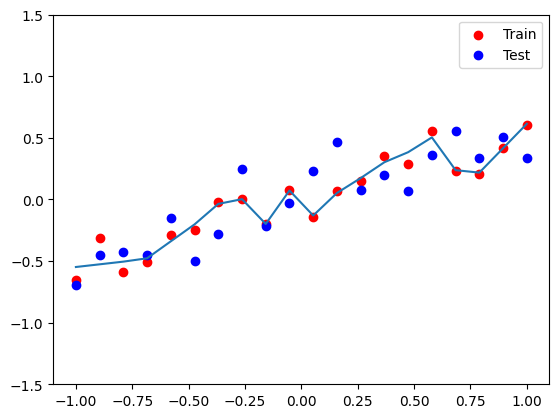

In [21]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_1)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

# we can clearly see tha our model has overfitted on the red training points and left out the blue test points

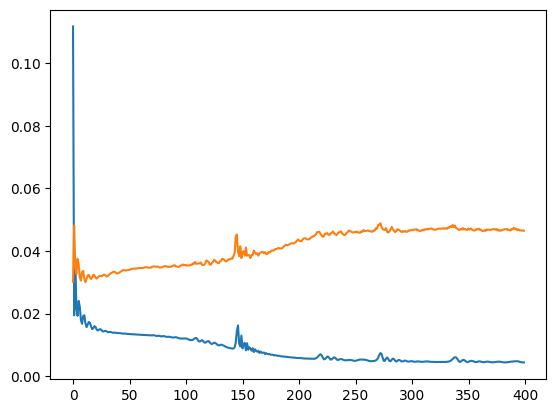

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# Dropout Model

In [36]:
model_2 = Sequential()
model_2.add(Dense(128, input_dim=1, activation="relu"))
model_2.add(Dropout(0.5)) # p=0.2 i.e in this hidden layer 20% neurons will be inactive
model_2.add(Dense(128, activation="relu"))
model_2.add(Dropout(0.5))
model_2.add(Dense(1, activation="linear"))
adam = Adam(learning_rate=0.01)


model_2.compile(loss='mse', optimizer=adam, metrics=['mse'])


drop_out_history = model_2.fit(X_train, y_train, epochs=400, 
                               validation_data = (X_test, y_test),
                               verbose=False)

/home/midori/Desktop/Nural_Network/nural_venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
regression_with_dropout = model_2.save('regression_with_dropout.keras')

In [38]:
regression_with_dropout = load_model('regression_with_dropout.keras')

In [39]:
# evaluate the model
result2_train = regression_with_dropout.evaluate(X_train, y_train, verbose=0)
result2_test = regression_with_dropout.evaluate(X_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(result2_train, result2_test))

Train: [0.015559135004878044, 0.015559135004878044], Test: [0.03576432541012764, 0.03576432541012764]


In [40]:
y_pred_2 = regression_with_dropout.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [41]:
y_pred_2 = y_pred_2.flatten()

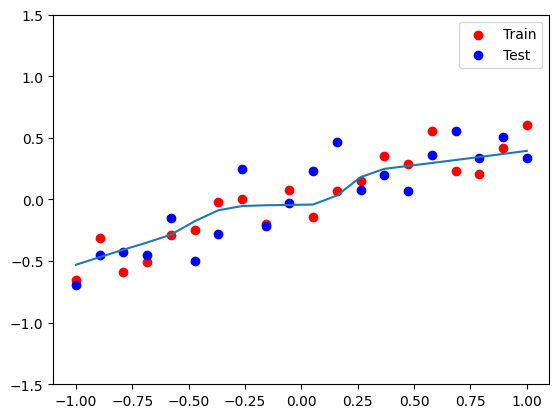

In [42]:
plt.figure()
plt.scatter(X_train, y_train, c='red', label='Train')
plt.scatter(X_test, y_test, c='blue', label='Test')
plt.plot(X_test, y_pred_2)
plt.legend()
plt.ylim((-1.5, 1.5))
plt.show()

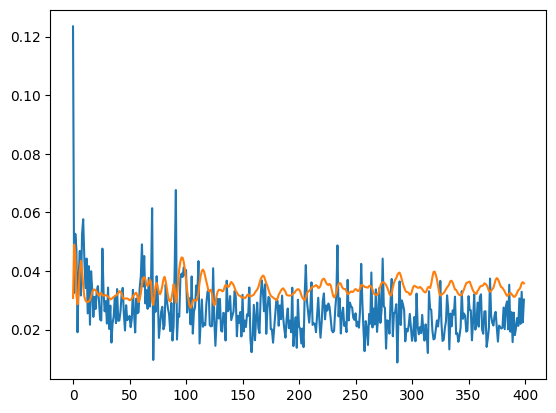

In [43]:
plt.plot(drop_out_history.history['loss'])
plt.plot(drop_out_history.history['val_loss'])